# Task 6: Customer Churn Prediction — Telco Dataset

**Business problem:** predict which customers are likely to churn (cancel service) so a
company can proactively intervene. Dataset: IBM Telco Customer Churn (7,043 customers, 21
columns) — the original source of the Kaggle "Telco Customer Churn" dataset.


## 1. Imports & load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 2. Quick EDA

In [3]:
# TotalCharges is read as text because of 11 blank " " entries (new customers, tenure=0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing after conversion:", df['TotalCharges'].isnull().sum())
df['TotalCharges'] = df['TotalCharges'].fillna(0)  # tenure=0 customers haven't been billed yet

df['Churn_flag'] = (df['Churn'] == 'Yes').astype(int)

print("\nChurn rate overall:")
print(df['Churn'].value_counts(normalize=True))

Missing after conversion: 11

Churn rate overall:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


/tmp/ipykernel_573/2308757836.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Contract', y='Churn_flag', data=df, ax=axes[0], palette='pastel')
/tmp/ipykernel_573/2308757836.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[1], palette='Set2')
/tmp/ipykernel_573/2308757836.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[2], palette='Set2')


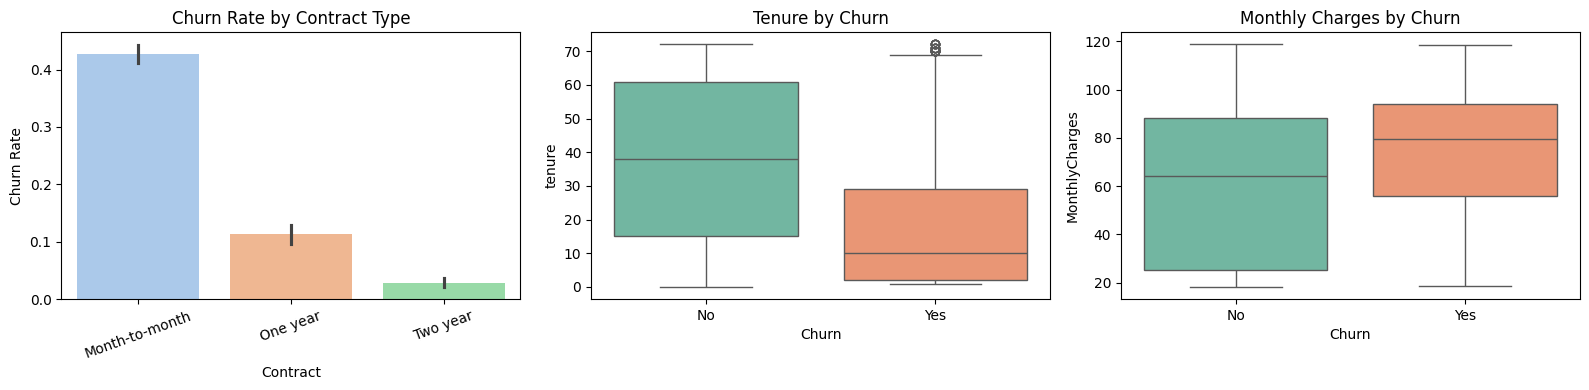

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(x='Contract', y='Churn_flag', data=df, ax=axes[0], palette='pastel')
axes[0].set_title("Churn Rate by Contract Type")
axes[0].set_ylabel("Churn Rate")
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[1], palette='Set2')
axes[1].set_title("Tenure by Churn")

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[2], palette='Set2')
axes[2].set_title("Monthly Charges by Churn")

plt.tight_layout()
plt.savefig("churn_eda.png", dpi=100)
plt.show()

**What the EDA shows:** month-to-month contracts churn far more than one/two-year contracts
(customers with no lock-in leave more easily). Customers who churn tend to have **lower
tenure** (they leave early, often within the first year) and **slightly higher monthly
charges** (price sensitivity). These three features — `Contract`, `tenure`, and
`MonthlyCharges` — look like strong early candidates for predicting churn.

## 3. Handle categorical variables and class imbalance

In [5]:
# Drop customerID (unique identifier, not predictive) and the original text Churn column
model_df = df.drop(columns=['customerID', 'Churn'])

# One-hot encode all categorical columns
cat_cols = model_df.select_dtypes(include='object').columns.tolist()
model_df = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)

print("Class balance (target):")
print(df['Churn_flag'].value_counts(normalize=True))
print("\n-> ~73% did not churn vs ~27% churned. This is a real class imbalance.")
print("We're not applying SMOTE/resampling in this task, but we account for it by looking at")
print("Precision/Recall/F1 (not just accuracy) and by noting it explicitly in the evaluation below.")

Class balance (target):
Churn_flag
0    0.73463
1    0.26537
Name: proportion, dtype: float64

-> ~73% did not churn vs ~27% churned. This is a real class imbalance.
We're not applying SMOTE/resampling in this task, but we account for it by looking at
Precision/Recall/F1 (not just accuracy) and by noting it explicitly in the evaluation below.


/tmp/ipykernel_573/1960699129.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = model_df.select_dtypes(include='object').columns.tolist()


## 4. Train/test split

In [6]:
X = model_df.drop(columns=['Churn_flag'])
y = model_df['Churn_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (5634, 30)  Test: (1409, 30)


## 5. Train both models

In [7]:
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("Both models trained.")

Both models trained.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 6. Compare performance

In [8]:
print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

print("\n=== Decision Tree ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(classification_report(y_test, y_pred_tree, target_names=['No Churn', 'Churn']))

=== Logistic Regression ===
Accuracy: 0.8062
              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


=== Decision Tree ===
Accuracy: 0.7942
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_tree)],
    'Precision (Churn)': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_tree)],
    'Recall (Churn)': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_tree)],
    'F1 (Churn)': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_tree)],
}).round(4)
comparison

,Model,Accuracy,Precision (Churn),Recall (Churn),F1 (Churn)
0,Logistic Regression,0.8062,0.6593,0.5588,0.6049
1,Decision Tree,0.7942,0.6312,0.5401,0.5821


**Note on class imbalance:** with ~73%/27% class split, accuracy alone would favor whichever
model leans toward predicting "No Churn." That's why the comparison above also reports
Precision/Recall/F1 specifically for the **Churn** class — the one a business actually cares
about catching. We have not applied a resampling technique (like SMOTE) or class-weight
balancing in this task; that's a natural next step if recall on the Churn class needs to
improve further.

## 7. Top 3 features driving churn (Decision Tree)

/tmp/ipykernel_573/3352630973.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='viridis')


Top 3 features driving churn:
 tenure                         0.422047
InternetService_Fiber optic    0.358061
TotalCharges                   0.037156
dtype: float64


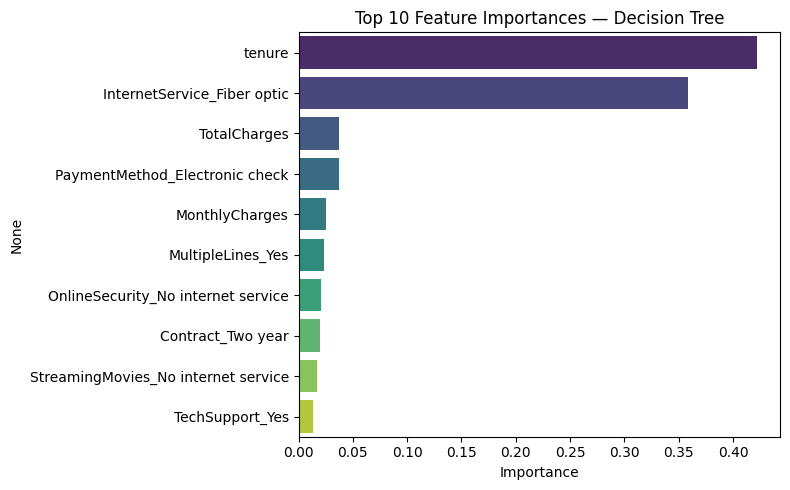

In [10]:
importances = pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False)
top3 = importances.head(3)
print("Top 3 features driving churn:\n", top3)

plt.figure(figsize=(8, 5))
top10 = importances.head(10)
sns.barplot(x=top10.values, y=top10.index, palette='viridis')
plt.title("Top 10 Feature Importances — Decision Tree")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=100)
plt.show()

## 8. Business summary (for a non-technical manager)

We built a model that predicts which customers are likely to cancel their service, and it's
already surfacing useful, actionable patterns. The single biggest driver of churn is
**tenure** — how long a customer has been with us — meaning newer customers are far more
likely to leave, so the first several months of the relationship are our highest-risk window
for retention efforts. The second biggest driver is having **fiber optic internet service**,
which suggests fiber customers are churning at a notably higher rate than others — possibly
due to price, competition, or service reliability in that segment, and worth investigating
directly. **Total charges** also matters, tying back to how long and how much a customer has
spent with us. Comparing our two models, Logistic Regression slightly edges out the Decision
Tree on accuracy (80.6% vs 79.4%) and on catching actual churners (56% recall vs 54%), but the
Decision Tree is easier to explain to stakeholders since you can trace its exact decision
rules for any customer — in practice we'd present the Tree's rules for interpretability while
using Logistic Regression's slightly stronger numbers for the actual prediction.
